# Linear optical properties

This note is used for checking linear optical properties

## Linear Optical Properties

* absorption coefficient

$$ \alpha(\omega)=\frac{\sqrt{2}\omega}{c}\left\{\left[\varepsilon_R^2(\omega)+\varepsilon_I^2(\omega)\right]^{\frac{1}{2}}-\varepsilon_R(\omega)\right\}^{\frac{1}{2}} $$

* refractive index

$$ n(\omega)=\frac{1}{\sqrt{2}}\left\{\left[\varepsilon_R^2(\omega)+\varepsilon_I^2(\omega)\right]^{\frac{1}{2}}+\varepsilon_R(\omega)\right\}^{\frac{1}{2}} $$

* extinction coefficient

$$ k(\omega)=\frac{1}{\sqrt{2}}\left\{\left[\varepsilon_R^2(\omega)+\varepsilon_I^2(\omega)\right]^{\frac{1}{2}}-\varepsilon_R(\omega)\right\}^{\frac{1}{2}} $$

* reflectivity

$$ n(\omega)=\frac{1}{\sqrt{2}}\left\{\left[\varepsilon_R^2(\omega)+\varepsilon_I^2(\omega)\right]^{\frac{1}{2}}+\varepsilon_R(\omega)\right\}^{\frac{1}{2}} $$

* energy loss spectrum

$$ L(\omega) = \frac{\varepsilon_I(\omega)}{\varepsilon^2_R(\omega)+\varepsilon_I^2(\omega)} $$

where:

$\omega$ is the given frequency;

$\varepsilon_R$ is real part dielectric function;

$\varepsilon_I$ is real part dielectric function.

References:

    10.1039/C7RA10570C

    vaspkit.com/tutorials.html#linear-optical-properties


In [1]:
# Prowork

import matplotlib.pyplot as plt

from vmatplot.linear_optical_properties import *

from vmatplot.commons import extract_fermi, process_boundary, process_boundaries_scaling, extract_part
from vmatplot.output import canvas_setting, color_sampling
from vmatplot.algorithms import energy_to_wavelength, energy_to_frequency


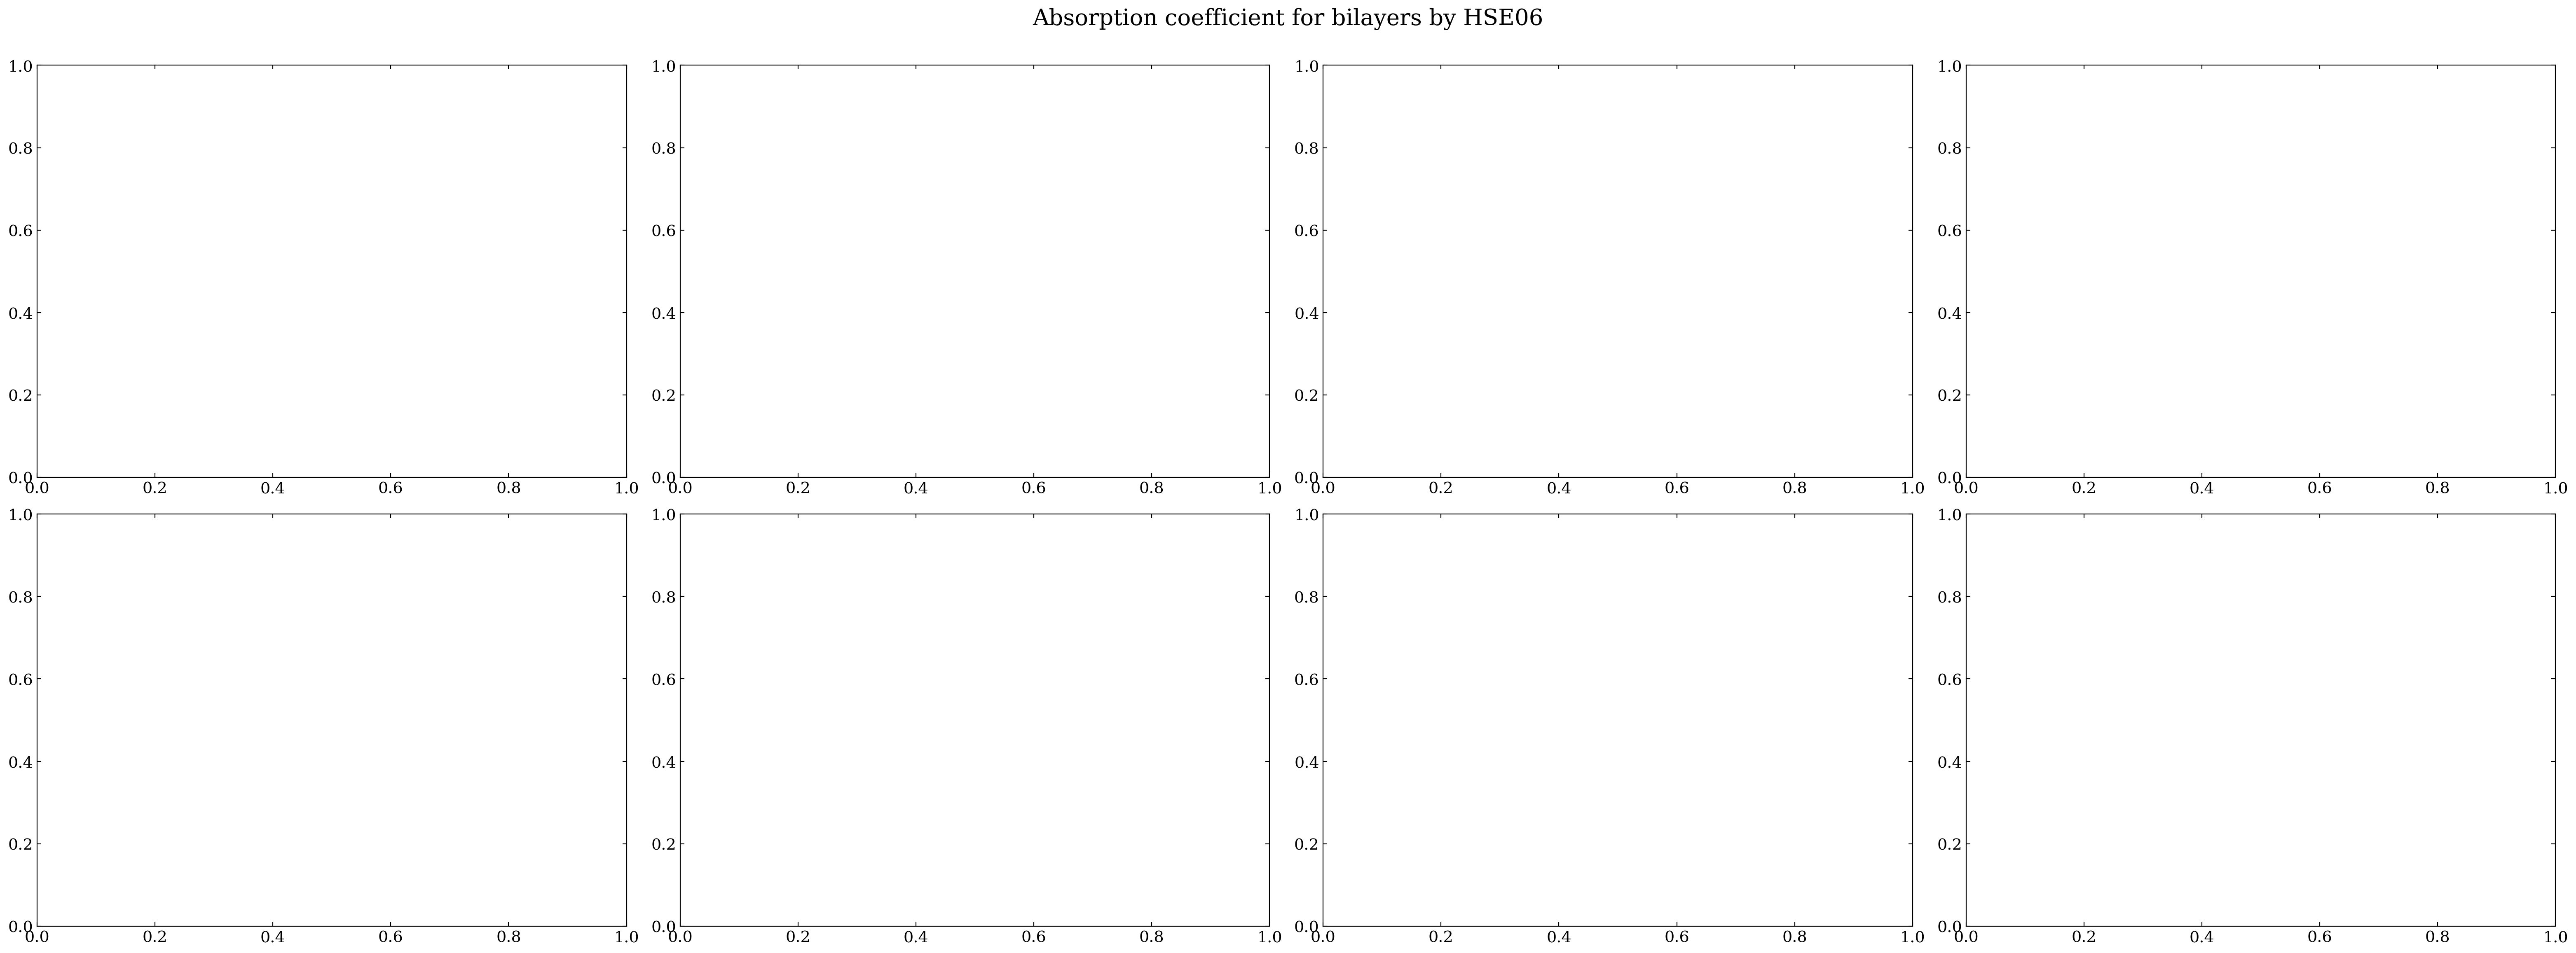

In [2]:
import inspect

def plot_linear_optical_property(suptitle, systems=None, current_property=None, components=None, layout="horizontal",
                                 unit="eV", boundary=(None,None), figure_size=(None,None)):
    ## Help information
    current_help = lop_plotting_help("absorption")
    if suptitle.lower() =="help":
        print(current_help)

    ## scale flag and databoundaries
    scale_flag, source_start, source_end, scaled_start, scaled_end = process_boundaries_scaling(boundary)

    ## components aliases
    component_keys, comp_aliases = [], []
    for comp in components:
        if isinstance(comp, dict):
            for key, value in comp.items():
                component_keys.append(f"{key}-component")
                comp_aliases.append(value)
        else:
            component_keys.append(f"{comp}-component")
            comp_aliases.append(f"{comp}-component")

    ## figure settings
    if scale_flag is True:
        if layout.lower() not in ["vertical", "ver"]:
            layout_flag = "horizontal"
            fig_setting = canvas_setting(8*len(components), 12) if figure_size == (None, None) else canvas_setting(figure_size[0], figure_size[1])
            params = fig_setting[2]
            plt.rcParams.update(params)
            fig, axs = plt.subplots(2, len(components), figsize=fig_setting[0], dpi=fig_setting[1])
            axes_element = [axs[i, j] for j in range(len(components)) for i in range(2)] if len(components) != 1 else [axs[0], axs[1]]
        else:
            layout_flag = "vertical"
            fig_setting = canvas_setting(16, 6*len(components)) if figure_size == (None, None) else canvas_setting(figure_size[0], figure_size[1])
            params = fig_setting[2]
            plt.rcParams.update(params)
            fig, axs = plt.subplots(len(components), 2, figsize=fig_setting[0], dpi=fig_setting[1])
            axes_element = [axs[i, j] for i in range(len(components)) for j in range(2)] if len(components) != 1 else [axs[0], axs[1]]
    else:
        if layout.lower() not in ["vertical", "ver"]:
            layout_flag = "horizontal"
            fig_setting = canvas_setting(8*len(components), 6) if figure_size == (None, None) else canvas_setting(figure_size[0], figure_size[1])
            params = fig_setting[2]
            plt.rcParams.update(params)
            fig, axs = plt.subplots(1, len(components), figsize=fig_setting[0], dpi=fig_setting[1])
            axes_element = [axs[i] for i in range(len(components))]
        else:
            layout_flag = "vertical"
            fig_setting = canvas_setting(8, 6*len(components)) if figure_size == (None, None) else canvas_setting(figure_size[0], figure_size[1])
            params = fig_setting[2]
            plt.rcParams.update(params)
            fig, axs = plt.subplots(len(components), 1, figsize=fig_setting[0], dpi=fig_setting[1])
            axes_element = [axs[i] for i in range(len(components))]

    ## identify x-axis unit
    var_label = "wavelength" if unit and unit.lower() == "nm" else "energy"
    xaxis_str = "Photon wavelength (nm)" if var_label == "wavelength" else "Photon energy (eV)"

    ## systems information
    dataset = lop_systems(systems)
    component_keys = [comp.lower() + "-component" for comp in components] if not comp_aliases else comp_aliases

    ## formula flag
    formula_flag = identify_linear_optical_functions(current_property)["flag"]

    ## suptitle
    suptitle_prefix = identify_linear_optical_functions(formula_flag)["title"]
    fig.suptitle(f"{suptitle_prefix} {suptitle}\n", fontsize=fig_setting[3][0])

    ## data plotting
    # scale_flag is True (scaling opened)
    if scale_flag is True:
        for supplot_index in range(2*len(components)):
            ax = axes_element[supplot_index]
            ax.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)

            # initialization
            wavelength_starts, wavelength_ends, energy_starts, energy_ends = [], [], [], []
            if supplot_index%2 == 0:
                x_start = source_start
                x_end = source_end
            else:
                x_start = scaled_start
                x_end = scaled_end

            # current component index and label
            component_index = supplot_index // 2
            if isinstance(components[component_index], dict):
                current_component = list(components[component_index].keys())[0]
            else:
                current_component = components[component_index].lower()
            data_key_real = f"density_{current_component}_real"
            data_key_imag = f"density_{current_component}_imag"

            # curve plotting
            for _, data in enumerate(dataset):
                energy_real_full, energy_imag_full = data[1]["density_energy_real"], data[1]["density_energy_imag"]
                density_real_full, density_imag_full = data[1][data_key_real], data[1][data_key_imag]
                wavelength_real_full = energy_to_wavelength(energy_real_full)
                frequency_real_full = energy_to_frequency(energy_real_full)
                
                # calculate curve
                if formula_flag == "absorption":
                    curve_full = current_lop(formula_flag, frequency_real_full, density_real_full, density_imag_full)
                else:
                    curve_full = current_lop(density_real_full, density_imag_full)

                # if var_label == "energy":
    
    # scale_flag is False (scaling closed)
    else:
        for supplot_index in range(len(components)):
            ax = axes_element[supplot_index]
            ax.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)

            # initialization
            wavelength_starts, wavelength_ends, energy_starts, energy_ends = [], [], [], []
            x_start = source_start
            x_end = source_end

            # current component index and label
            component_index = supplot_index
            if isinstance(components[component_index], dict):
                current_component = list(components[component_index].keys())[0]
            else:
                current_component = components[component_index].lower()
            data_key_real = f"density_{current_component}_real"
            data_key_imag = f"density_{current_component}_imag"

            # curve plotting
            for _, data in enumerate(dataset):
                energy_real, density_energy_real = extract_part(data[1]["density_energy_real"], data[1][data_key_real], x_start, x_end)
                energy_imag, density_energy_imag = extract_part(data[1]["density_energy_imag"], data[1][data_key_imag], x_start, x_end)
                wavelength_real = energy_to_wavelength(energy_real)
                frequency_real = energy_to_frequency(energy_real)

                # calculate curve
                if formula_flag == "absorption":
                    curve_full = current_lop(formula_flag, frequency_real_full, density_real_full, density_imag_full)
                else:
                    curve_full = current_lop(density_real_full, density_imag_full)

    plt.tight_layout()

systems = [["Graphene-BC₃ (17 k-points)", "5_Dielectric_function/E_Graphene-BC3_HSE_K17", "blue"],
           ["Graphene-Borophene", "5_Dielectric_function/F_Graphene-Borophene_HSE_K65_Accurate", "green"],
           ["Graphene-B₄C₃ (17 k-points)", "5_Dielectric_function/G_Graphene-B4C3_HSE_K17", "violet"]]

components = [{"xx":"in-plane"}, {"zz":"out-of-plane"}, "xy", "yx"]
boundary = (24,8)

plot_linear_optical_property("for bilayers by HSE06", systems, "absorption", components, "hor", "eV", boundary)

# plot_linear_optical_property("for bilayers by HSE06", systems, "absorption", components, "ver", "eV", boundary)


In [3]:
def plot_refractive_index(suptitle, systems=None, components=None,
                          layout="horizontal", unit="eV", boundary=(None,None), figure_size=(None,None)):
    ## Help information
    current_help = lop_plotting_help("refractive")
    if suptitle.lower() =="help":
        print(current_help)

    plt.tight_layout()

plot_refractive_index("help")

def plot_extinction_coefficient(suptitle, systems=None, components=None,
                                layout="horizontal", unit="eV", boundary=(None,None), figure_size=(None,None)):
    ## Help information
    current_help = lop_plotting_help("extinction")
    if suptitle.lower() =="help":
        print(current_help)

    plt.tight_layout()

# plot_extinction_coefficient("help")

def plot_reflectivity(suptitle, systems=None, components=None,
                      layout="horizontal", unit="eV", boundary=(None,None), figure_size=(None,None)):
    ## Help information
    current_help = lop_plotting_help("extinction")
    if suptitle.lower() =="help":
        print(current_help)

    plt.tight_layout()

# plot_reflectivity("help")

def plot_energy_loss_spectrum(suptitle, systems=None, components=None,
                              layout="horizontal", unit="eV", boundary=(None,None), figure_size=(None,None)):
    ## Help information
    current_help = lop_plotting_help("energy-loss")
    if suptitle.lower() =="help":
        print(current_help)

    plt.tight_layout()

def plot_energy_loss_function(*args):
    return plot_energy_loss_spectrum(*args)

# plot_energy_loss_spectrum("help")


Usage: plot_refractive_index 
Demonstrate refractive by each component 
	 suptitle: the suptitle; 
	 systems: dielectric function data list; 
	 components: planes ('xx'<default>, 'yy', 'zz', 'xy', 'yx', 'yz', 'zy', 'zx', 'xz'); 
	 layout: subfigures layout (horizontal<default>, vertical); 
	 unit: x-axis unit (eV<default>, nm); 
	 boundary: a-axis range <optional>; 
	 figure_size: figure size <optional>. 



<Figure size 640x480 with 0 Axes>

In [4]:
def plot_linear_optical_properties(suptitle, systems=None, properties=None, components=None, layout="horizontal", expansion_label=True,
                                   unit="eV", boundary=(None,None), figure_size=(None,None)):
    help_info = f"Usage: plot_linear_optical_properties \n" +\
                f"Demonstrate linear optical properties by each component \n" +\
                "\t suptitle: the suptitle; \n" +\
                "\t systems: dielectric function data list; \n" +\
                "\t properties: what properties are required; \n" +\
                "\t components: planes ('xx'<default>, 'yy', 'zz', 'xy', 'yx', 'yz', 'zy', 'zx', 'xz'); \n" +\
                "\t expansion_label: whether to each component (True<default>, False); \n" +\
                "\t layout: subfigures layout (horizontal<default>, vertical); \n" +\
                "\t unit: x-axis unit (eV<default>, nm); \n" +\
                "\t boundary: a-axis range <optional>; \n" +\
                "\t figure_size: figure size <optional>. \n"
    if suptitle.lower() =="help":
        print(help_info)

    ## expansion flag
    if isinstance(expansion_label, bool):
        expansion_flag = expansion_label
    elif expansion_label.lower() not in ["true", "yes", "t", "y", "combine"]:
        expansion_flag = False
    else:
        expansion_flag = True

    plt.tight_layout()

plot_linear_optical_properties("for bilayers by HSE06", systems, components, layout, "True", "eV", boundary)


NameError: name 'layout' is not defined